In [ ]:
# Ver la información de la GPU disponible
!nvidia-smi
# Conectar Google Drive para acceder al dataset
from google.colab import drive
drive.mount('/content/drive')

/bin/bash: line 1: nvidia-smi: command not found
Mounted at /content/drive


In [ ]:
# Buscar en Drive el archivo del dataset escogido y descargado de Roboflow
!find /content/drive/MyDrive -name "persons.v3i.yolo26.zip"

/content/drive/MyDrive/persons.v3i.yolo26.zip


In [ ]:
# Descomprimir el dataset en el entorno de trabajo
!unzip "/content/drive/MyDrive/persons.v3i.yolo26.zip" -d /content/

Archive:  /content/drive/MyDrive/persons.v3i.yolo26.zip
replace /content/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
# Crear el archivo de configuración del dataset para YOLO
%%writefile /content/data_colab.yaml

path: /content

train: train/images
val: valid/images
test: test/images

names:
  0: person

Overwriting /content/data_colab.yaml


In [ ]:
# Instalar la librería Ultralytics (YOLO)
!pip -q install ultralytics

# Importar función para comprobar que el dataset está bien configurado
from ultralytics.data.utils import check_det_dataset

# Cargar y verificar el archivo de configuración del dataset
data = check_det_dataset("/content/data_colab.yaml")
print(data)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
{'path': PosixPath('/content'), 'train': '/content/train/images', 'val': '/content/valid/images', 'test': '/content/test/images', 'names': {0: 'person'}, 'yaml_file': '/content/data_colab.yaml', 'nc': 1, 'channels': 3}


In [ ]:
# Crear una carpeta en Google Drive para guardar los resultados del entrenamiento y no perderlos al salir de Colab
!mkdir -p /content/drive/MyDrive/yolo_training

In [ ]:
# Instalar ClearML para monitorizar mejor el entrenamiento
!pip -q install clearml
import os
# Configurar las credenciales de ClearML, elimino mis credenciales en la entrega
os.environ["CLEARML_API_ACCESS_KEY"] = "XXXXXXXXXX"
os.environ["CLEARML_API_SECRET_KEY"] = "XXXXXXXXXXX"
os.environ["CLEARML_API_HOST"] = "https://api.clear.ml"
os.environ["CLEARML_WEB_HOST"] = "https://app.clear.ml"
os.environ["CLEARML_FILES_HOST"] = "https://files.clear.ml"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.1 MB/s eta 0:00:00


In [ ]:
# Crear una tarea en ClearML para monitorizar el entrenamiento
from clearml import Task

task = Task.init(
    project_name="YOLO_roboflow",
    task_name="person_detect_roboflow"
)

ClearML Task: created new task id=e21582ba394c4b49bb05bf2599171247


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)


ClearML results page: https://app.clear.ml/projects/df4994e6b96740ac924a1f28c720d9c4/experiments/e21582ba394c4b49bb05bf2599171247/output/log


Ultralytics 8.4.20 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data_colab.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=person_detect_roboflow2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d0f78d2d6a0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

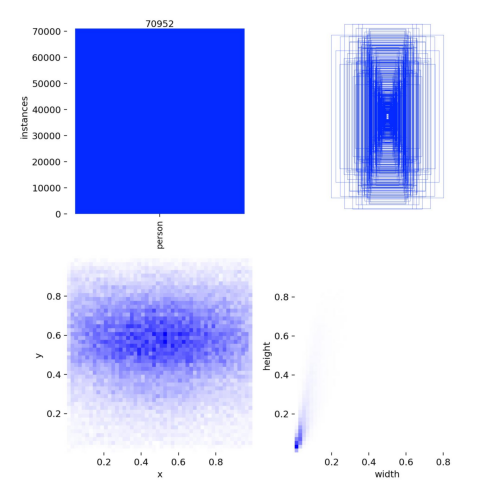

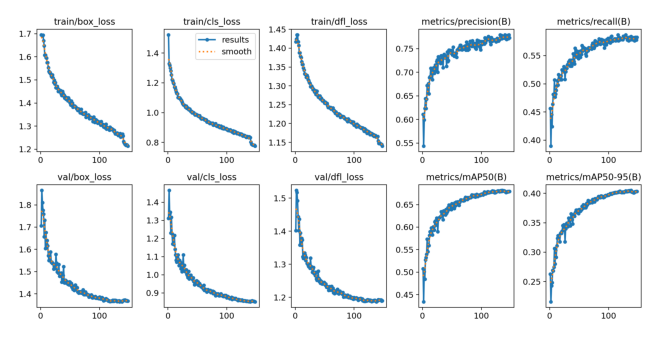

█████████████████████████████████ 100% | 5.97/5.97 MB [00:00<00:00, 10.90MB/s]: 


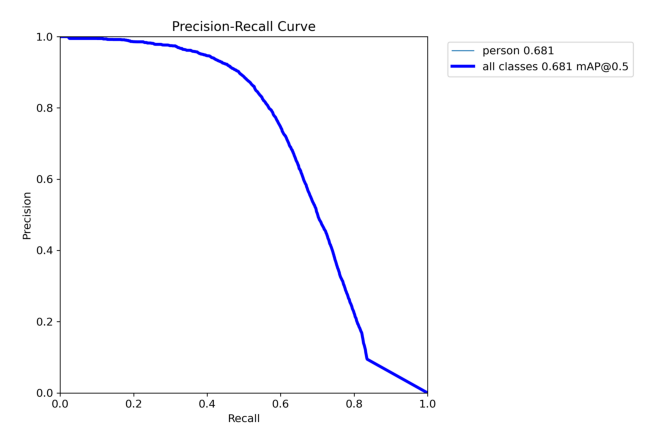

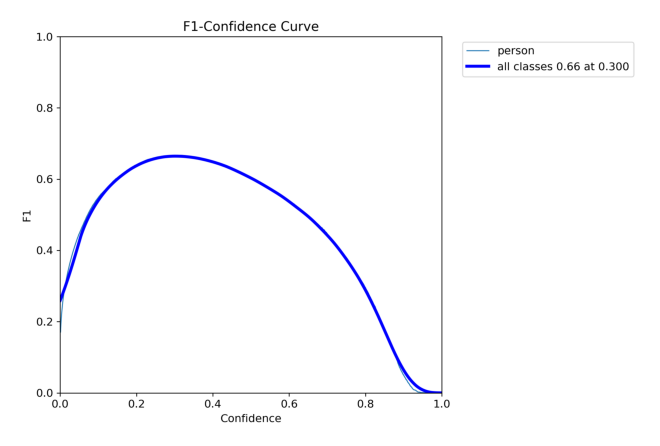

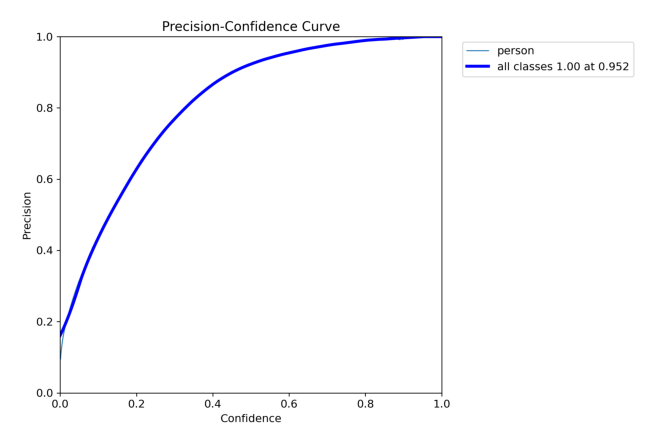

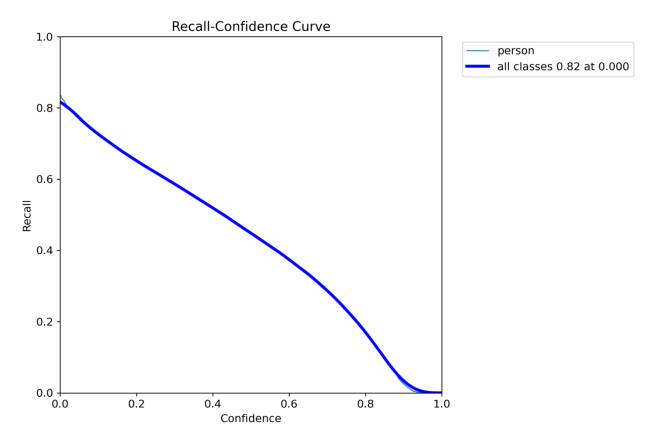

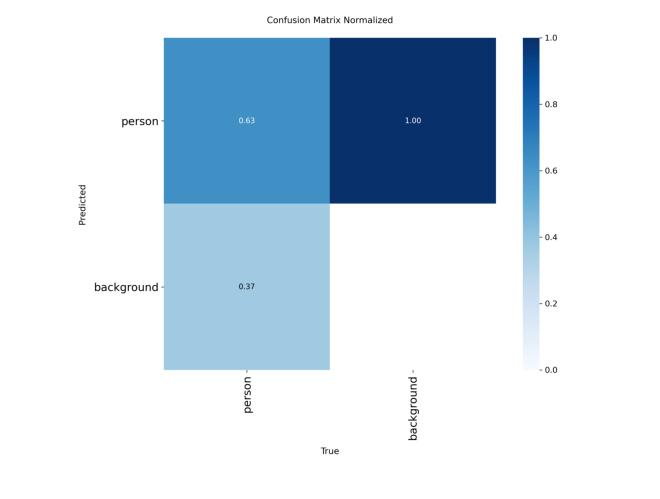

In [ ]:
# Importar la librería YOLO de Ultralytics
from ultralytics import YOLO

# Cargar el modelo base preentrenado YOLOV8N,SE HAN INTENTADO OTROS MODELOS 8S, 26, PERO EL TIEMPO DE ENTRENAMIENTO SUBÍA DEMASIADO Y ALCANZABA EL TIEMPO LÍMITE DE USO DE COLAB
model = YOLO("yolov8n.pt")

# Entrenar el modelo
model.train(
    data="/content/data_colab.yaml", # archivo de configuración del dataset
    epochs=150, # número de épocas de entrenamiento, fijo 150 para evitar alcanzar el tiempo límite de uso de Colab con GPU (entorno a 3 horas)
    patience=10, # parar si no mejora
    imgsz=640, # tamaño de las imágenes
    batch=16,  # número de imágenes por batch
    device=0, # usar la GPU disponible
    pretrained=True, # usar pesos preentrenados

    # Guardar resultados directamente en Google Drive para no perder los resultados al salir de Colab
    project="/content/drive/MyDrive/yolo_training",
    name="person_detect_roboflow",
    exist_ok=False
)

In [ ]:
# Descargar un video de ejemplo con personas para probar el detector
!wget -O people-detection.mp4 https://github.com/intel-iot-devkit/sample-videos/raw/master/people-detection.mp4

--2026-03-05 16:05:12--  https://github.com/intel-iot-devkit/sample-videos/raw/master/people-detection.mp4
Resolving github.com (github.com)... 20.205.243.166
Connecting to github.com (github.com)|20.205.243.166|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/people-detection.mp4 [following]
--2026-03-05 16:05:13--  https://raw.githubusercontent.com/intel-iot-devkit/sample-videos/master/people-detection.mp4
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5482579 (5.2M) [application/octet-stream]
Saving to: ‘people-detection.mp4’

people-detection.mp 100%[===================>]   5.23M  --.-KB/s    in 0.03s   

2026-03-05 16:05:13 (208 MB/s) - ‘people-detecti

In [ ]:
# Ejecutar la detección de personas sobre el video descargado
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo_training/person_detect_roboflow/weights/best.pt")

model.predict(
    source="people-detection.mp4",
    imgsz=640,
    conf=0.2,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/596) /content/people-detection.mp4: 384x640 (no detections), 11.5ms
video 1/1 (frame 2/596) /content/people-detection.mp4: 384x640 (no detections), 10.6ms
video 1/1 (frame 3/596) /content/people-detection.mp4: 384x640 (no detections), 10.6ms
video 1/1 (frame 4/596) /content/people-detection.mp4: 384x640 (no detections), 10.6ms
video 1/1 (frame 5/596) /content/people-detection.mp4: 384x640 (no detections), 10.6ms
video 1/1 (frame 6/596)

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[116, 111, 123],
         [116, 111, 123],
         [116, 111, 123],
         ...,
         [ 85,  77,  85],
         [ 85,  77,  85],
         [ 85,  77,  85]],
 
        [[116, 111, 123],
         [116, 111, 123],
         [116, 111, 123],
         ...,
         [ 85,  77,  85],
         [ 85,  77,  85],
         [ 85,  77,  85]],
 
        [[116, 111, 123],
         [116, 111, 123],
         [116, 111, 123],
         ...,
         [ 85,  77,  85],
         [ 85,  77,  85],
         [ 85,  77,  85]],
 
        ...,
 
        [[142, 135, 146],
         [141, 134, 145],
         [140, 133, 144],
         ...,
         [149, 145, 155],
         [149, 145, 155],
         [149, 145, 155]],
 
        [[141, 134, 145],
         [140, 133, 144],
         [139, 132, 143],
         ...,
         [147, 140

In [ ]:
# Buscar los archivos de video generados tras la inferencia
!find runs/detect -maxdepth 2 -type f \( -name "*.avi" -o -name "*.mp4" \) -print

runs/detect/predict/person-bicycle-car-detection.avi
runs/detect/predict2/people-detection.avi


In [ ]:
# Convertir el video generado (.avi) a formato .mp4 para poder visualizarlo
!ffmpeg -y -i runs/detect/predict2/people-detection.avi -c:v libx264 -pix_fmt yuv420p people-detection_out.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# Mostrar el video final con las detecciones
from IPython.display import Video

Video("people-detection_out.mp4", embed=True)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Descargar el video con las detecciones
from google.colab import files
files.download("people-detection_out.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Descargar otro video de ejemplo con varias personas para probar el detector
!wget -O crowd_people.avi https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi

--2026-03-05 18:59:42--  https://github.com/opencv/opencv/raw/master/samples/data/vtest.avi
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi [following]
--2026-03-05 18:59:43--  https://raw.githubusercontent.com/opencv/opencv/master/samples/data/vtest.avi
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 8131690 (7.8M) [video/msvideo]
Saving to: ‘crowd_people.avi’

crowd_people.avi    100%[===================>]   7.75M  --.-KB/s    in 0.02s   

2026-03-05 18:59:44 (325 MB/s) - ‘crowd_people.avi’ saved [8131690/8131690]



In [ ]:
# Convertir el video descargado de formato .avi a .mp4
!ffmpeg -i crowd_people.avi -vcodec libx264 crowd_people.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# Ejecutar la detección de personas sobre el segundo video de prueba
from ultralytics import YOLO

model = YOLO("/content/drive/MyDrive/yolo_training/person_detect_roboflow/weights/best.pt")

model.predict(
    source="crowd_people.mp4",
    imgsz=640,
    conf=0.2,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/795) /content/crowd_people.mp4: 480x640 3 persons, 686.4ms
video 1/1 (frame 2/795) /content/crowd_people.mp4: 480x640 3 persons, 463.5ms
video 1/1 (frame 3/795) /content/crowd_people.mp4: 480x640 3 persons, 465.1ms
video 1/1 (frame 4/795) /content/crowd_people.mp4: 480x640 3 persons, 450.1ms
video 1/1 (frame 5/795) /content/crowd_people.mp4: 480x640 3 persons, 473.8ms
video 1/1 (frame 6/795) /content/crowd_people.mp4: 480x640 3 persons

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'person'}
 obb: None
 orig_img: array([[[104, 142, 177],
         [105, 143, 178],
         [105, 143, 178],
         ...,
         [ 58,  83, 109],
         [ 69,  80, 108],
         [ 38,  49,  77]],
 
        [[105, 143, 178],
         [105, 143, 178],
         [105, 143, 178],
         ...,
         [ 52,  77, 103],
         [ 70,  81, 109],
         [ 42,  53,  81]],
 
        [[105, 143, 178],
         [105, 143, 178],
         [105, 143, 178],
         ...,
         [ 50,  75, 101],
         [ 75,  86, 114],
         [ 48,  59,  87]],
 
        ...,
 
        [[  0,  35,  20],
         [  0,  35,  20],
         [  0,  36,  21],
         ...,
         [  9,  72,  60],
         [ 11,  74,  62],
         [ 11,  74,  62]],
 
        [[  0,  35,  20],
         [  0,  35,  20],
         [  0,  36,  21],
         ...,
         [  8,  71

In [ ]:
# Buscar los videos generados tras la inferencia
!find runs/detect -maxdepth 2 -type f \( -name "*.avi" -o -name "*.mp4" \) -print

runs/detect/predict/crowd_people.avi


In [ ]:
# Convertir el video a formato .mp4 para poder visualizar el resultado
!ffmpeg -i crowd_people.avi -vcodec libx264 crowd_people_out.mp4

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [ ]:
# Mostrar el contenido de la carpeta donde se guardan las predicciones
!ls -lh runs/detect
# Buscar los videos generados
!find runs/detect -maxdepth 2 -type f \( -name "*.mp4" -o -name "*.avi" \) -print -exec ls -lh {} \;

total 4.0K
drwxr-xr-x 2 root root 4.0K Mar  5 19:04 predict
runs/detect/predict/crowd_people.avi
-rw-r--r-- 1 root root 66M Mar  5 19:11 runs/detect/predict/crowd_people.avi


In [ ]:
# Convertir el video con las detecciones a .mp4 para visualizarlo
!apt-get install -y ffmpeg

!ffmpeg -y -i runs/detect/predict/crowd_people.avi \
  -vcodec libx264 -pix_fmt yuv420p -movflags +faststart \
  runs/detect/predict/crowd_people_bb.mp4

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --

In [ ]:
# Mostrar el video final con las detecciones de personas
from IPython.display import Video
Video("runs/detect/predict/crowd_people_bb.mp4", embed=True)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# Descargar el video final con las detecciones
from google.colab import files
files.download("runs/detect/predict/crowd_people_bb.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>